## Check the clustering measurements on region splits

In [5]:
from pathlib import Path
import numpy as np
import lsstypes as types
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from clustering_statistics import tools
from clustering_statistics.plotting_tools import get_means_covs
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
def unpack_stat(kind, stat, ells = (0,2), bins_type = 'test', cov=None):
    if 'mesh2_spectrum' in kind:
        ells = list(ells)
        # sl = slice(0, None, 1)  # rebin to dk = 0.001 h/Mpc
        sl = slice(0, None, 5)  # rebin to dk = 0.001 h/Mpc
        oklim = (0, 0.3)  # fitted k-range, no need to go to higher k
        stat = stat.select(k=sl).select(k=oklim).get(ells)
        if cov is not None:
            cov = cov.at.observable.match(stat)
            std = np.sqrt(np.diag(cov.value()))
            n_per_ell = len(std) // len(ells)
            std = {ell: std[i*n_per_ell:(i+1)*n_per_ell] for i, ell in enumerate(ells)}
        else:
            std = {ell: None for ell in ells}
        k = stat.get(ells=0).coords('k')
        Pk = {ell: {"value": stat.get(ells=ell).values()['value'], "std": std[ell]} for ell in stat.ells}
        return k, Pk

In [2]:
project = 'full_shape/data_splits'

data_cases = {'data-dr2-v2':  {'version': 'data-dr2-v2', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False}}
cov_cases = {'holi-v3-altmtl':   {'version': 'holi-v3-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False},}

default_bin = [
('BGS', (0.1, 0.4)),
('LRG', (0.4, 0.6)),
('LRG', (0.6, 0.8)),
('LRG', (0.8, 1.1)),
('ELG', (0.8, 1.1)),
('ELG', (1.1, 1.6)),
('QSO', (0.8, 2.1))
][1:4]

regions = ['GCcomb', 'NS', 'GCcomb_noN', 'GCcomb_noDES'][:1]
regions += ['NGC', 'SGC', 'N', 'NGCnoN', 'S', 'SGCnoDES'] #galactic and imaging regions
regions += ['ACT_DR6', 'PLANCK_PR4']+ [f'GAL0{i}' for i in [40, 60]] #lensing regions
# colors = ['C0', 'k', 'C1', 'k', 'C2', 'k', 'C3', 'k', 'C4', 'k']
# lss = ['-', ':']*5
lss = ['-']*len(regions)

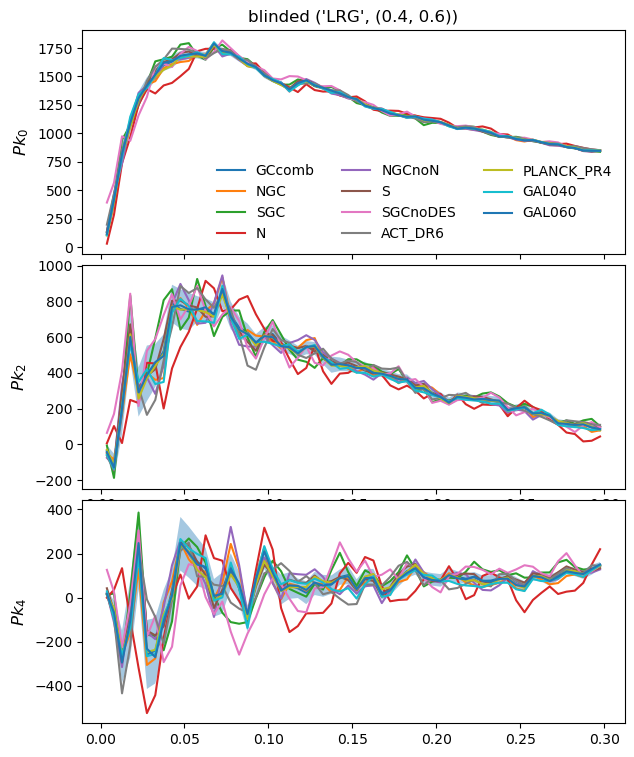

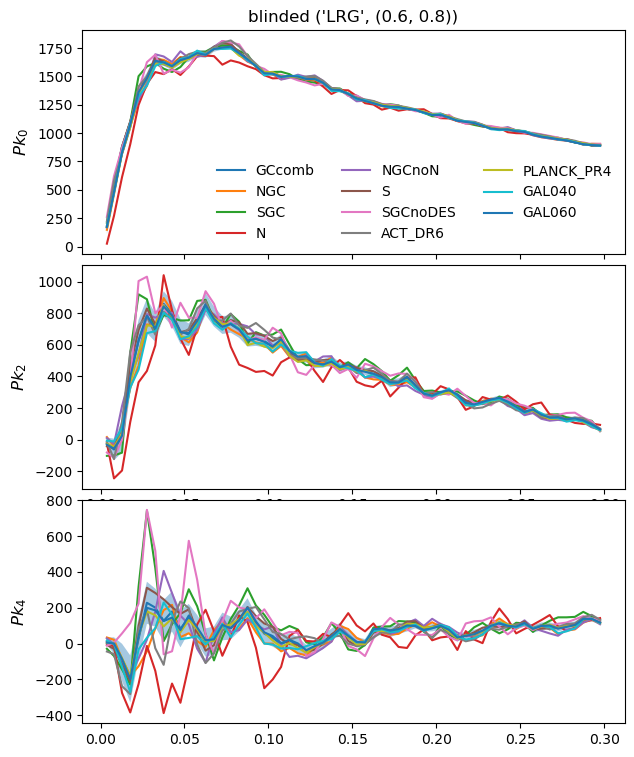

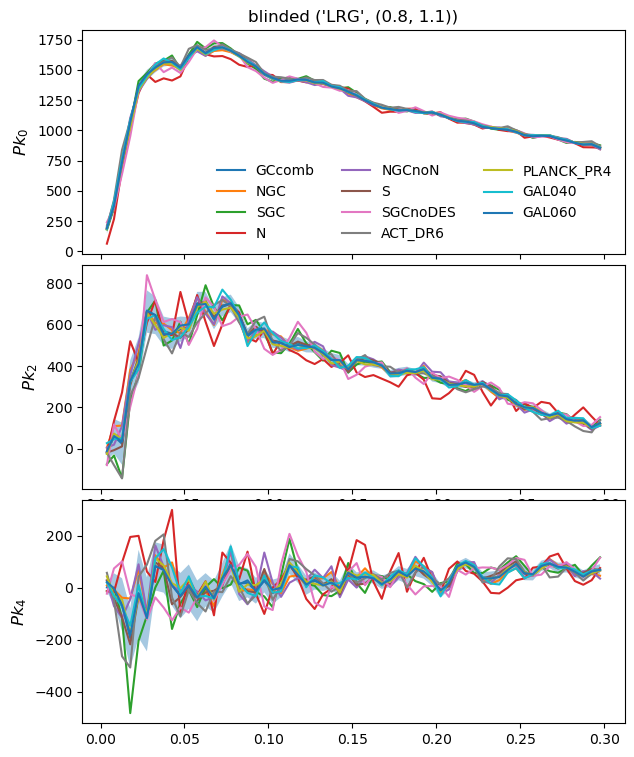

In [4]:
kind = 'mesh2_spectrum_poles'
ells = (0, 2, 4)
for (tracer, zrange) in default_bin :
    fig = plt.figure(figsize=(7, 3*len(ells)))
    gs = gridspec.GridSpec(len(ells), 1, wspace=0., hspace=0.05, height_ratios=[1, 1, 1])
    title = f'{tracer, zrange}'
    if 'BGS' in tracer: tracer = 'BGS_BRIGHT-21.35'
    if 'ELG' in tracer: tracer = 'ELG_LOPnotqso'
    for rind, region in enumerate(regions):
        args = dict(kind=kind, versions=data_cases, tracer=tracer,zrange=zrange, region=region, stats_dir=tools.base_stats_dir, project=f'{project}/blinded_data')
        data_stat = get_means_covs(**args)[0]["data-dr2-v2"]
        (k, Pk) = unpack_stat(kind=kind, stat=data_stat, cov=None, ells=ells)
        if region == 'GCcomb':
            args.update(versions = cov_cases, project =project)
            (k, Pk) = unpack_stat(kind=kind, stat=data_stat, cov= get_means_covs(**args)[1]["holi-v3-altmtl"], ells=ells)
        for ell in ells:
            ax = plt.subplot(gs[int(ell/2)])
            ax.plot(k, k*Pk[ell]['value'], label=region, color=f'C{rind}', ls=lss[rind])
            if region == 'GCcomb':
                ax.fill_between(k,k*(Pk[ell]['value']-Pk[ell]['std']), k*(Pk[ell]['value']+Pk[ell]['std']), alpha=0.4)
            ax.set_ylabel(r'$Pk_{{{0:d}}}$'.format(ell), fontsize=12)
            if ell == 0:
                ax.legend(loc=4, ncols = 3, frameon=False, fontsize=10)
                ax.set_title(f'blinded {title}')
            if ell == 2:
                ax.set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]', fontsize=10)

{'kind': 'mesh2_spectrum_poles', 'versions': {'holi-v3-altmtl': {'version': 'holi-v3-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False}}, 'tracer': 'LRG', 'zrange': (0.6, 0.8), 'region': 'SGCnoDES', 'stats_dir': PosixPath('/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics'), 'project': 'full_shape/data_splits'}
